In [2]:
import pandas as pd
import numpy as np
import json


In [3]:
df = pd.read_excel('../data/output/kopken_tweet_with_predicted_aspect_test.xlsx', sheet_name='Sheet1')
df

Traceback (most recent call last):
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 500, in _repr_dw_
    return self._gen_json()
           ^^^^^^^^^^^^^^^^
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 508, in _gen_json
    return api["pandas_transport"]["get_df_payload"](tmp_vars[self.id]["converted"], max_num_rows_to_preload, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 248, in get_df_payload
    return get_df_payload_v0(df, row_limit, **extra_props)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 240, in get_df_payload_v0
    return pd_dumps({
           ^^^^^^^^^^
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 217, in pd_dumps
    return

,Date,Text,Text Normalization,Sentimen,Predicted_Aspects,Predicted_Keywords
0,01/2024,"oiya,, kopken.. makasih. maaf ya gapteks nih, ...",oiya kopi kenangan terima kasih maaf gapteks t...,negative,Layanan Pelanggan,"makasih, maaf, gapteks"
1,01/2024,"it's always, kopi susu tetangga tuku, palm sug...",its always kopi susu tetangga tuku palm gula l...,positive,Kualitas Kopi; Suasana/Tempat,"kopi susu, palm sugar latte, less sugar, rasa ..."
2,01/2024,Always latte kopi kenangan,always latte kopi kenangan,positive,NaN,NaN
3,01/2024,good day sama kopi kenangan,good day kopi kenangan,positive,NaN,NaN
4,01/2024,good day sama kopi kenangan sii,good day kopi kenangan sii,positive,NaN,NaN
...,...,...,...,...,...,...
1588,12/2024,@FOODFESS2 ada yang pernahh cobain milkbun kop...,pernahh cobain milkbun kopi kenangan yaa ripyu...,neutral,Menu Lain,milkbun
1589,12/2024,Strong semua tomoro. Mending ke kopken,strong tomoro kopi kenangan,negative,Kualitas Kopi,Strong
1590,12/2024,Dua kali. Kopi Kenangan Mantan dan Fore Butter...,kopi kenangan fore buttercream tiramisu latte,positive,Menu Lain,"Kopi Kenangan Mantan, Fore Buttercream Tiramis..."
1591,12/2024,kopken juga lagi,kopi kenangan,positive,NaN,NaN


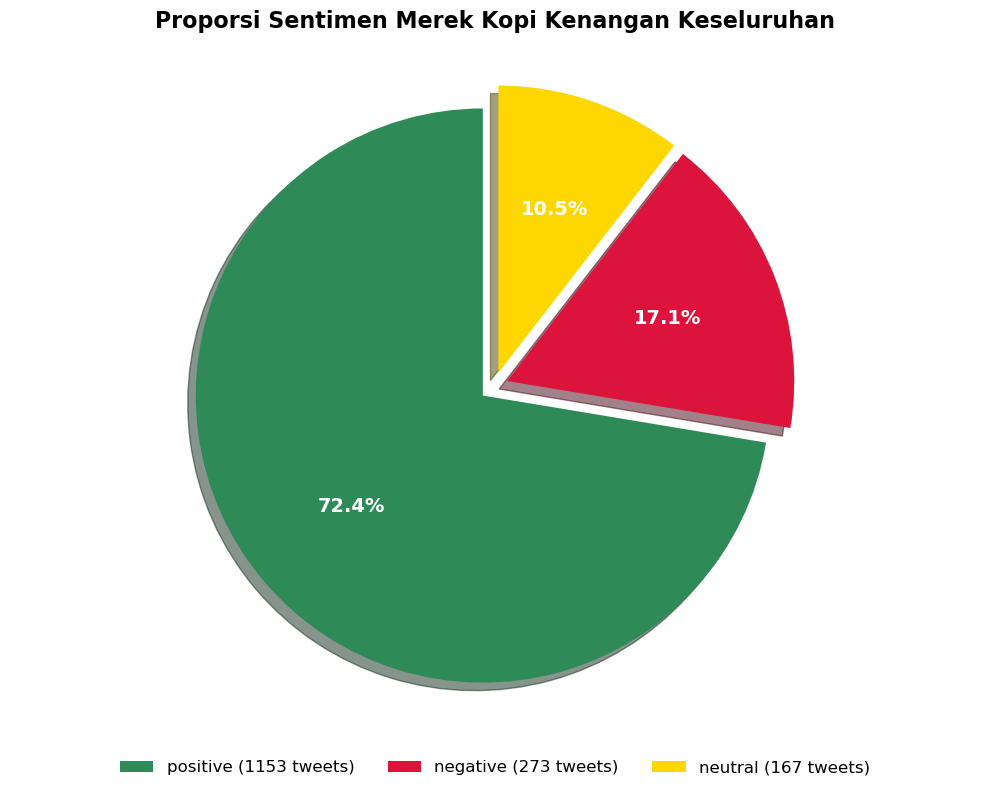

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

sentiment_counts = df['Sentimen'].value_counts()

plt.figure(figsize=(10, 8))
colors = ['#2E8B57', '#DC143C', '#FFD700']  # Green, Gold, Red
wedges, texts, autotexts = plt.pie(sentiment_counts, 
                                  autopct='%1.1f%%', 
                                  startangle=90, 
                                  colors=colors,
                                  explode=(0.05, 0.05, 0.05),
                                  shadow=True,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Enhance the percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')



plt.title('Proporsi Sentimen Merek Kopi Kenangan Keseluruhan', fontsize=16, fontweight='bold', pad=20)

# Create horizontal legend below the chart
legend_labels = [f'{label} ({count} tweets)' for label, count in zip(sentiment_counts.index, sentiment_counts.values)]
plt.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           fontsize=12, frameon=False)

plt.axis('equal')
plt.tight_layout()
plt.show()

In [5]:
# Split rows where Predicted_Aspects has multiple values
df_expanded = df.copy()
df_expanded['Predicted_Aspects'] = df_expanded['Predicted_Aspects'].str.split('; ')
df_expanded = df_expanded.explode('Predicted_Aspects').reset_index(drop=True)
df_expanded

Traceback (most recent call last):
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 500, in _repr_dw_
    return self._gen_json()
           ^^^^^^^^^^^^^^^^
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 508, in _gen_json
    return api["pandas_transport"]["get_df_payload"](tmp_vars[self.id]["converted"], max_num_rows_to_preload, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 248, in get_df_payload
    return get_df_payload_v0(df, row_limit, **extra_props)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 240, in get_df_payload_v0
    return pd_dumps({
           ^^^^^^^^^^
  File "C:\Users\atrke\AppData\Local\Temp\ipykernel_13100\2682650136.py", line 217, in pd_dumps
    return

,Date,Text,Text Normalization,Sentimen,Predicted_Aspects,Predicted_Keywords
0,01/2024,"oiya,, kopken.. makasih. maaf ya gapteks nih, ...",oiya kopi kenangan terima kasih maaf gapteks t...,negative,Layanan Pelanggan,"makasih, maaf, gapteks"
1,01/2024,"it's always, kopi susu tetangga tuku, palm sug...",its always kopi susu tetangga tuku palm gula l...,positive,Kualitas Kopi,"kopi susu, palm sugar latte, less sugar, rasa ..."
2,01/2024,"it's always, kopi susu tetangga tuku, palm sug...",its always kopi susu tetangga tuku palm gula l...,positive,Suasana/Tempat,"kopi susu, palm sugar latte, less sugar, rasa ..."
3,01/2024,Always latte kopi kenangan,always latte kopi kenangan,positive,NaN,NaN
4,01/2024,good day sama kopi kenangan,good day kopi kenangan,positive,NaN,NaN
...,...,...,...,...,...,...
2060,12/2024,Strong semua tomoro. Mending ke kopken,strong tomoro kopi kenangan,negative,Kualitas Kopi,Strong
2061,12/2024,Dua kali. Kopi Kenangan Mantan dan Fore Butter...,kopi kenangan fore buttercream tiramisu latte,positive,Menu Lain,"Kopi Kenangan Mantan, Fore Buttercream Tiramis..."
2062,12/2024,kopken juga lagi,kopi kenangan,positive,NaN,NaN
2063,12/2024,kalau aku janjiw gak terlalu suka malah aku be...,janjiw gak suka berharapnya kopi kenangan vers...,negative,Kualitas Kopi,"janjiw, gak terlalu suka; versi gerobaknyaa"


In [6]:
# Remove rows where Predicted_Aspects is 'nan'
df_expanded = df_expanded[df_expanded['Predicted_Aspects'] != 'nan']
df_expanded = df_expanded[df_expanded['Predicted_Aspects'] != 'ERROR']
print(df_expanded['Predicted_Aspects'].value_counts())

Predicted_Aspects
Kualitas Kopi        800
Menu Lain            625
Harga/Nilai          149
Suasana/Tempat       133
Promo                 66
Layanan Pelanggan     43
Name: count, dtype: int64


<Figure size 1400x800 with 0 Axes>

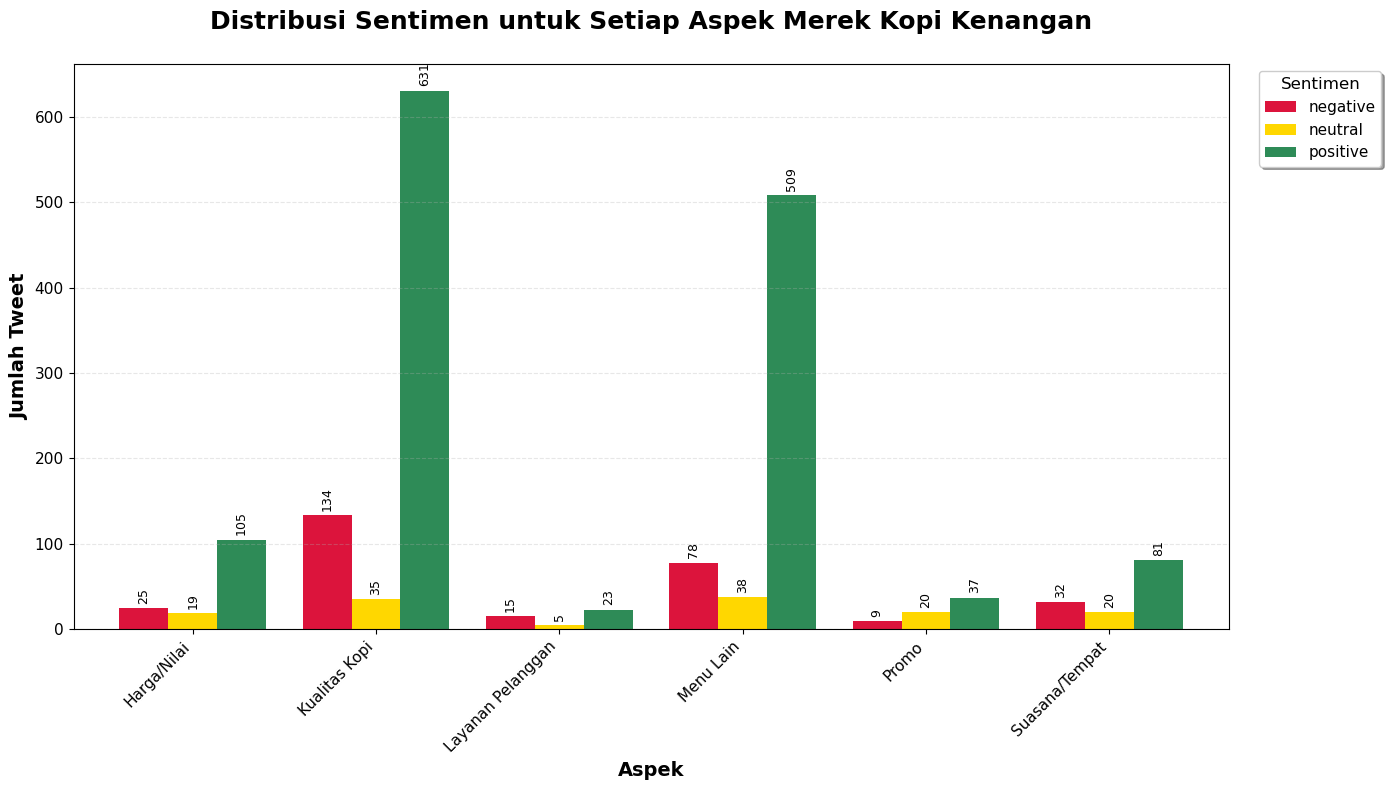

DISTRIBUSI SENTIMEN PER ASPEK
Sentimen           negative  neutral  positive
Predicted_Aspects                             
Harga/Nilai              25       19       105
Kualitas Kopi           134       35       631
Layanan Pelanggan        15        5        23
Menu Lain                78       38       509
Promo                     9       20        37
Suasana/Tempat           32       20        81

PERSENTASE SENTIMEN PER ASPEK
Sentimen           negative  neutral  positive
Predicted_Aspects                             
Harga/Nilai            16.8     12.8      70.5
Kualitas Kopi          16.8      4.4      78.9
Layanan Pelanggan      34.9     11.6      53.5
Menu Lain              12.5      6.1      81.4
Promo                  13.6     30.3      56.1
Suasana/Tempat         24.1     15.0      60.9


In [15]:
# Create a crosstab to see sentiment distribution for each aspect
aspect_sentiment = pd.crosstab(df_expanded['Predicted_Aspects'], df_expanded['Sentimen'])

# Create a grouped bar chart with better styling
plt.figure(figsize=(14, 8))
ax = aspect_sentiment.plot(kind='bar', 
                          color=['#DC143C', '#FFD700', '#2E8B57'], 
                          figsize=(14, 8),
                          width=0.8)

# Enhance the plot styling
plt.title('Distribusi Sentimen untuk Setiap Aspek Merek Kopi Kenangan', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Aspek', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Tweet', fontsize=14, fontweight='bold')

# Customize legend
plt.legend(title='Sentimen', title_fontsize=12, fontsize=11, 
           bbox_to_anchor=(1.02, 1), loc='upper left',
           frameon=True, fancybox=True, shadow=True)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Add grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on bars
for container in ax.containers:
    ax.bar_label(container, fontsize=9, rotation=90, padding=3)

# Improve layout
plt.tight_layout()
plt.show()

# Display the numerical breakdown with better formatting
print("="*60)
print("DISTRIBUSI SENTIMEN PER ASPEK")
print("="*60)
print(aspect_sentiment)
print("\n" + "="*60)
print("PERSENTASE SENTIMEN PER ASPEK")
print("="*60)
aspect_sentiment_pct = pd.crosstab(df_expanded['Predicted_Aspects'], df_expanded['Sentimen'], normalize='index') * 100
print(aspect_sentiment_pct.round(1))

<Figure size 800x600 with 0 Axes>

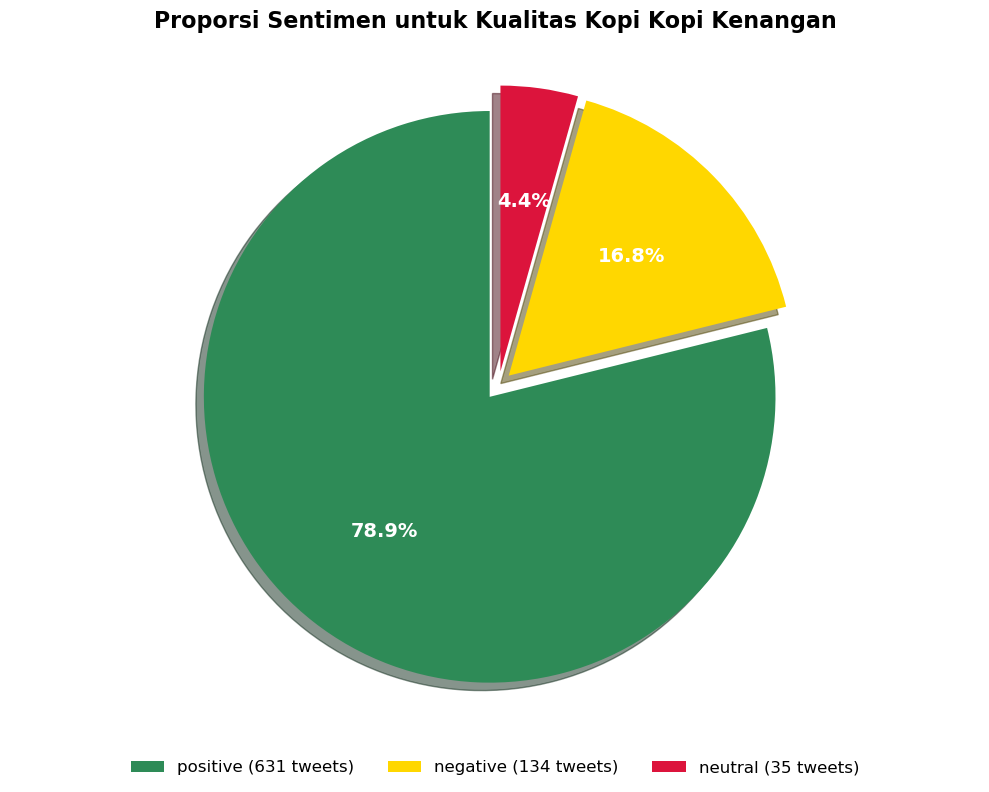

In [8]:
# pie chart for Kualitas Kopi
kualitas_kopi = df_expanded[df_expanded['Predicted_Aspects'] == 'Kualitas Kopi']['Sentimen'].value_counts()
plt.figure(figsize=(8, 6))
plt.figure(figsize=(10, 8))
colors = ['#2E8B57', '#FFD700', '#DC143C']  # Green, Gold, Red
wedges, texts, autotexts = plt.pie(kualitas_kopi, 
                                  autopct='%1.1f%%', 
                                  startangle=90, 
                                  colors=colors,
                                  explode=(0.05, 0.05, 0.05),
                                  shadow=True,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Enhance the percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Create horizontal legend below the chart
legend_labels = [f'{label} ({count} tweets)' for label, count in zip(kualitas_kopi.index, kualitas_kopi.values)]
plt.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           fontsize=12, frameon=False)
plt.title('Proporsi Sentimen untuk Kualitas Kopi Kopi Kenangan', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

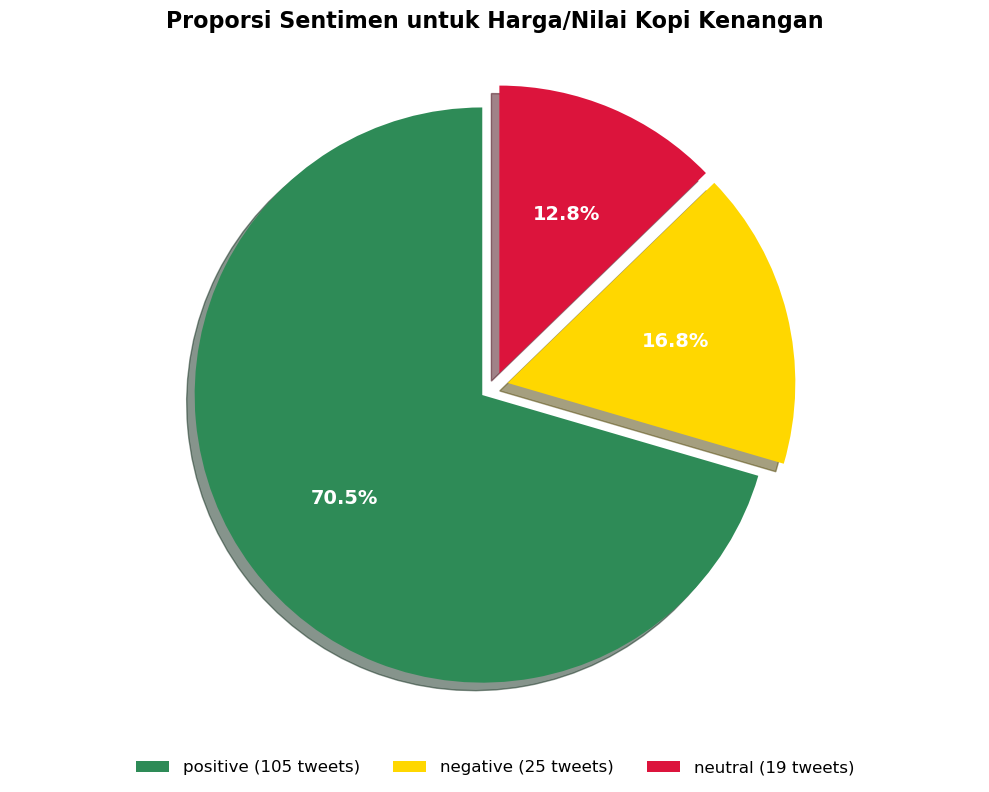

In [9]:
# pie chart for Harga/Nilai
var = 'Harga/Nilai'
target = df_expanded[df_expanded['Predicted_Aspects'] == var]['Sentimen'].value_counts()
plt.figure(figsize=(8, 6))
plt.figure(figsize=(10, 8))
colors = ['#2E8B57', '#FFD700', '#DC143C']  # Green, Gold, Red
wedges, texts, autotexts = plt.pie(target, 
                                  autopct='%1.1f%%', 
                                  startangle=90, 
                                  colors=colors,
                                  explode=(0.05, 0.05, 0.05),
                                  shadow=True,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Enhance the percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Create horizontal legend below the chart
legend_labels = [f'{label} ({count} tweets)' for label, count in zip(target.index, target.values)]
plt.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           fontsize=12, frameon=False)
plt.title(f'Proporsi Sentimen untuk {var} Kopi Kenangan', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

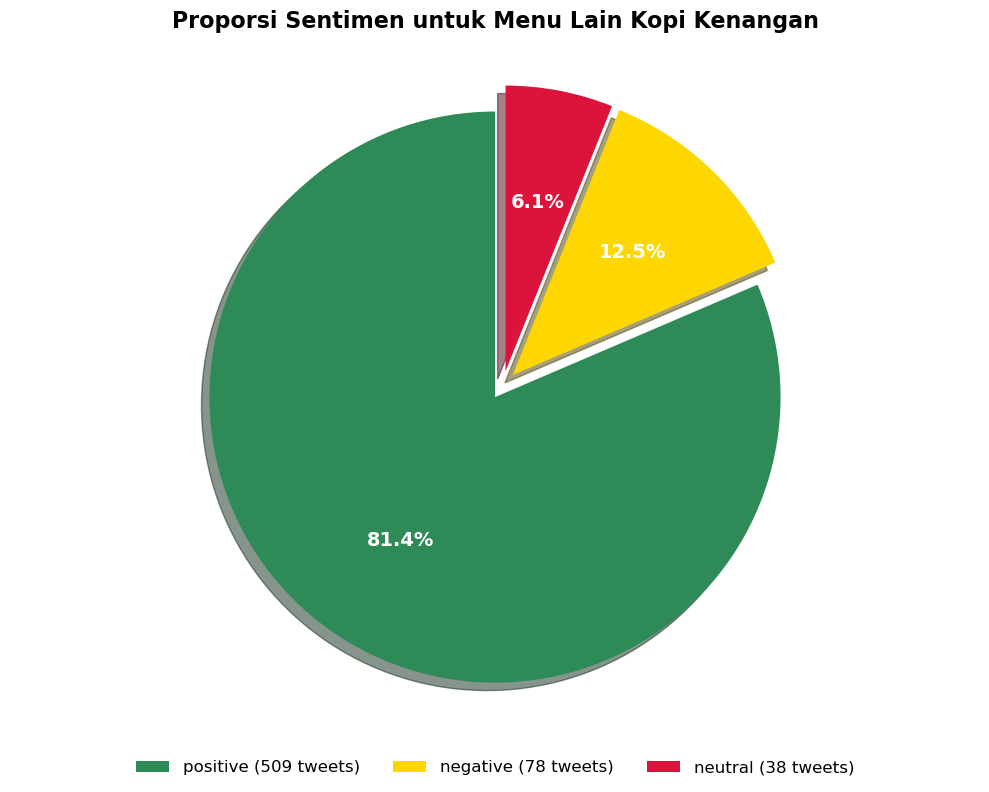

In [10]:
# pie chart for Menu Lain
var = 'Menu Lain'
target = df_expanded[df_expanded['Predicted_Aspects'] == var]['Sentimen'].value_counts()
plt.figure(figsize=(8, 6))
plt.figure(figsize=(10, 8))
colors = ['#2E8B57', '#FFD700', '#DC143C']  # Green, Gold, Red
wedges, texts, autotexts = plt.pie(target, 
                                  autopct='%1.1f%%', 
                                  startangle=90, 
                                  colors=colors,
                                  explode=(0.05, 0.05, 0.05),
                                  shadow=True,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Enhance the percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Create horizontal legend below the chart
legend_labels = [f'{label} ({count} tweets)' for label, count in zip(target.index, target.values)]
plt.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           fontsize=12, frameon=False)
plt.title(f'Proporsi Sentimen untuk {var} Kopi Kenangan', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

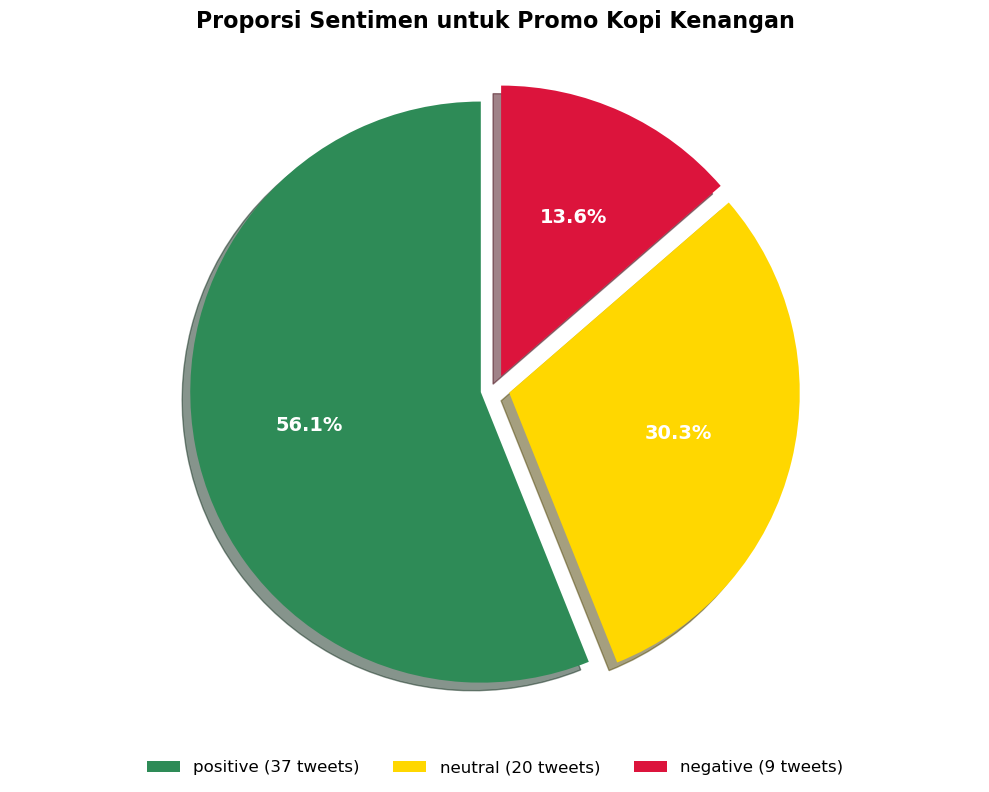

In [11]:
# pie chart for Promo
var = 'Promo'
target = df_expanded[df_expanded['Predicted_Aspects'] == var]['Sentimen'].value_counts()
plt.figure(figsize=(8, 6))
plt.figure(figsize=(10, 8))
colors = ['#2E8B57', '#FFD700', '#DC143C']  # Green, Gold, Red
wedges, texts, autotexts = plt.pie(target, 
                                  autopct='%1.1f%%', 
                                  startangle=90, 
                                  colors=colors,
                                  explode=(0.05, 0.05, 0.05),
                                  shadow=True,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Enhance the percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Create horizontal legend below the chart
legend_labels = [f'{label} ({count} tweets)' for label, count in zip(target.index, target.values)]
plt.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           fontsize=12, frameon=False)
plt.title(f'Proporsi Sentimen untuk {var} Kopi Kenangan', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

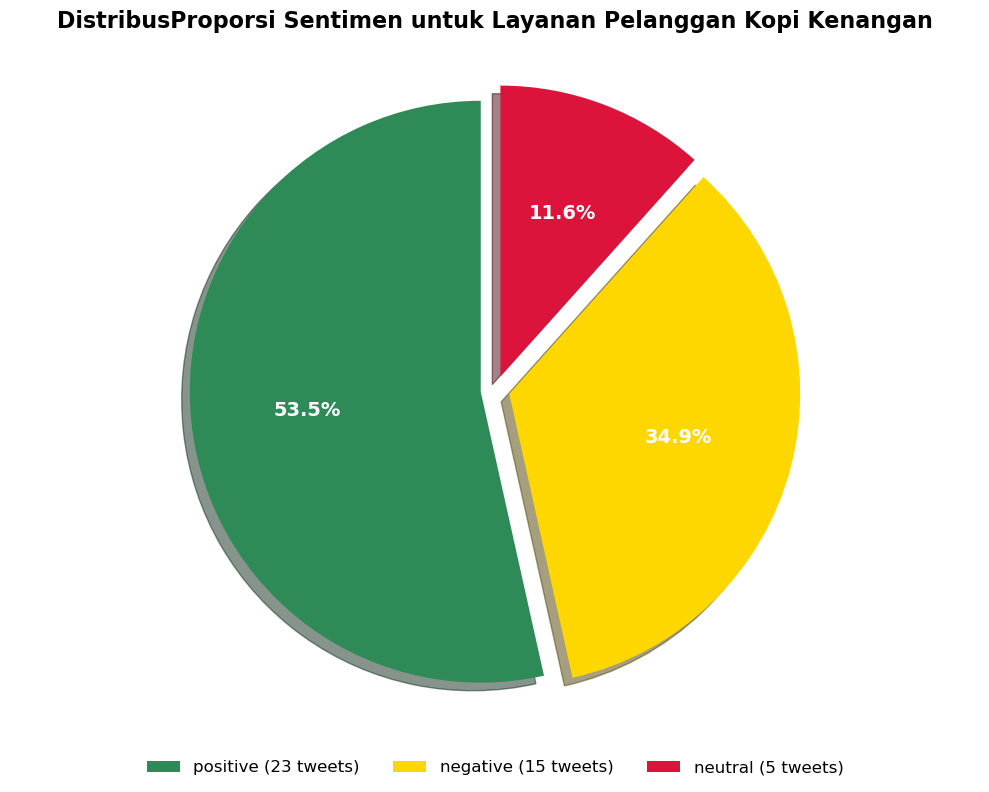

In [12]:
# pie chart for Layanan Pelanggan
var = 'Layanan Pelanggan'
target = df_expanded[df_expanded['Predicted_Aspects'] == var]['Sentimen'].value_counts()
plt.figure(figsize=(8, 6))
plt.figure(figsize=(10, 8))
colors = ['#2E8B57', '#FFD700', '#DC143C']  # Green, Gold, Red
wedges, texts, autotexts = plt.pie(target, 
                                  autopct='%1.1f%%', 
                                  startangle=90, 
                                  colors=colors,
                                  explode=(0.05, 0.05, 0.05),
                                  shadow=True,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Enhance the percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Create horizontal legend below the chart
legend_labels = [f'{label} ({count} tweets)' for label, count in zip(target.index, target.values)]
plt.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           fontsize=12, frameon=False)
plt.title(f'DistribusProporsi Sentimen untuk {var} Kopi Kenangan', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()


<Figure size 800x600 with 0 Axes>

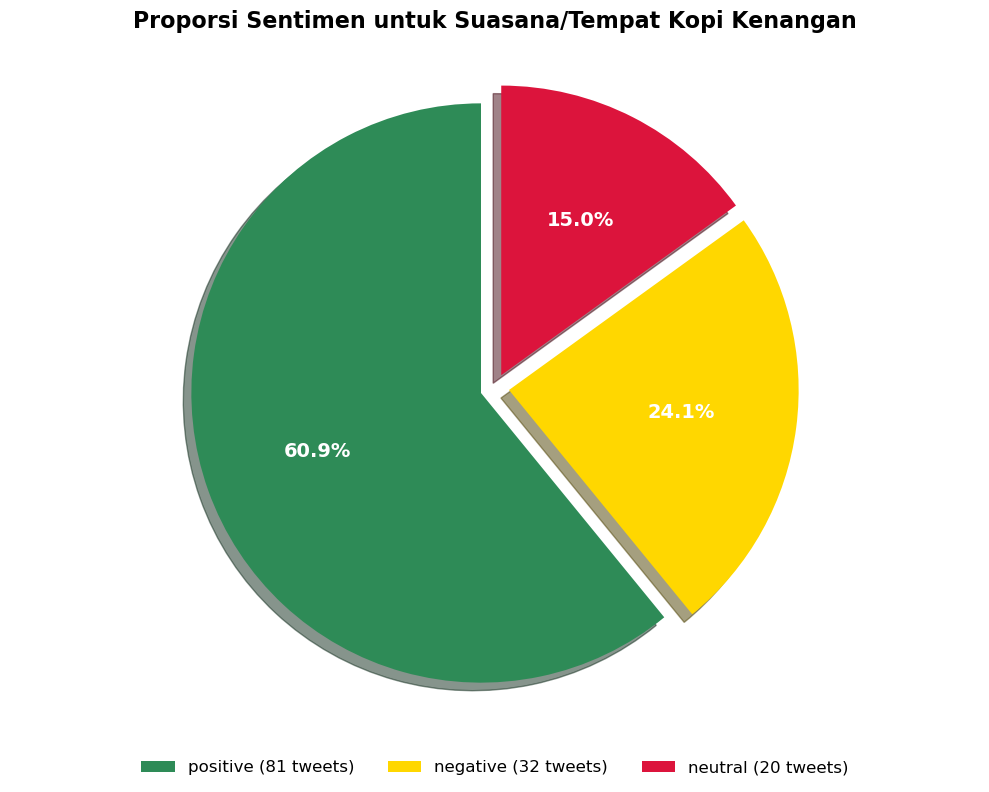

In [13]:
# pie chart for Suasana/Tempat
var = 'Suasana/Tempat'
target = df_expanded[df_expanded['Predicted_Aspects'] == var]['Sentimen'].value_counts()
plt.figure(figsize=(8, 6))
plt.figure(figsize=(10, 8))
colors = ['#2E8B57', '#FFD700', '#DC143C']  # Green, Gold, Red
wedges, texts, autotexts = plt.pie(target, 
                                  autopct='%1.1f%%', 
                                  startangle=90, 
                                  colors=colors,
                                  explode=(0.05, 0.05, 0.05),
                                  shadow=True,
                                  textprops={'fontsize': 12, 'fontweight': 'bold'})

# Enhance the percentage labels
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(14)
    autotext.set_fontweight('bold')

# Create horizontal legend below the chart
legend_labels = [f'{label} ({count} tweets)' for label, count in zip(target.index, target.values)]
plt.legend(wedges, legend_labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, 
           fontsize=12, frameon=False)
plt.title(f'Proporsi Sentimen untuk {var} Kopi Kenangan', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()


In [14]:
from collections import Counter
import re

# Create top 10 words by aspects and sentiment


# 0. Definisikan semua stopwords sekaligus (brand + umum)
brand_stopwords = {
    'fore', 'tomoro', 'kopi', 'kenangan', 'kopi kenangan',
    'point', 'coffee', 'point coffee',
    'kopikenangan', 'pointcoffee', 'kenangancoffee',
    'tuku', 'kopken', 'janjiw', 'famima', 'calf', 'esteh indonesia', 'couvee', 'sushi tei','fami'
}

common_stopwords = {
    'dan', 'yang', 'ini', 'itu', 'dari', 'untuk', 'dengan',
    'ke', 'pada', 'atau', 'yg', 'aku', 'kamu', 'kita',
    'lagi', 'lagi', 'boleh', 'mau', 'ga', 'gak', 'aja',
    'sih', 'si', 'nya', 'sama', 'bisa', 'ada', 'juga',
    'buat', 'kayak', 'tuh', 'pake', 'tp', 'nama'
}
stop_words = set(w.lower() for w in brand_stopwords | common_stopwords)

# 1. Fungsi untuk split & filter keywords
def extract_words(keywords_text):
    if pd.isna(keywords_text) or not keywords_text:
        return []
    # Split di koma atau titik-koma
    tokens = re.split(r'[;,]', str(keywords_text))
    cleaned = []
    for tok in tokens:
        w = tok.strip().lower()
        # Hapus stopwords, brand, dan kata terlalu pendek
        if len(w) > 2 and w not in stop_words:
            cleaned.append(w)
    return cleaned

# Create a comprehensive analysis
results = {}

# Get unique aspects and sentiments
aspects = df_expanded['Predicted_Aspects'].dropna().unique()
sentiments = df_expanded['Sentimen'].unique()

print("TOP 10 KATA BERDASARKAN ASPEK DAN SENTIMEN\n" + "="*50)

for aspect in aspects:
    results[aspect] = {}
    print(f"\n📊 ASPEK: {aspect.upper()}")
    print("-" * 40)
    
    for sentiment in sentiments:
        # Filter data for specific aspect and sentiment
        filtered_data = df_expanded[
            (df_expanded['Predicted_Aspects'] == aspect) & 
            (df_expanded['Sentimen'] == sentiment)
        ]
        
        if len(filtered_data) > 0:
            # Extract all words from keywords for this combination
            all_words = []
            for keywords in filtered_data['Predicted_Keywords']:
                all_words.extend(extract_words(keywords))
            
            # Count word frequencies
            word_counts = Counter(all_words)
            top_10 = word_counts.most_common(10)
            
            results[aspect][sentiment] = top_10
            
            print(f"\n{sentiment.upper()} ({len(filtered_data)} tweets):")
            if top_10:
                for i, (word, count) in enumerate(top_10, 1):
                    print(f"  {i:2d}. {word:<15} ({count:2d}x)")
            else:
                print("     Tidak ada kata kunci yang tersedia")
        else:
            print(f"\n{sentiment.upper()}: Tidak ada data")

print("\n" + "="*50)
print("RINGKASAN ANALISIS SELESAI")

TOP 10 KATA BERDASARKAN ASPEK DAN SENTIMEN

📊 ASPEK: LAYANAN PELANGGAN
----------------------------------------

NEGATIVE (15 tweets):
   1. less sugar      ( 3x)
   2. no sugar        ( 3x)
   3. makasih         ( 1x)
   4. maaf            ( 1x)
   5. gapteks         ( 1x)
   6. kasta kopi      ( 1x)
   7. janjiw ngga akan pernah masuk lagi ( 1x)
   8. trauma seumur hidup ( 1x)
   9. ditanya         ( 1x)
  10. kakaknya nanya sekali lagi ( 1x)

POSITIVE (23 tweets):
   1. matcha          ( 7x)
   2. enak            ( 6x)
   3. less sugar      ( 5x)
   4. discount        ( 3x)
   5. gratis          ( 3x)
   6. thai tea        ( 3x)
   7. minta less sugar ( 2x)
   8. tiap hari beli  ( 2x)
   9. kentel          ( 2x)
  10. kemanisan       ( 2x)

NEUTRAL (5 tweets):
   1. less sugar      ( 2x)
   2. kak             ( 2x)
   3. pilih           ( 2x)
   4. minta no sugar  ( 1x)
   5. minta           ( 1x)
   6. matcha latte    ( 1x)
   7. order dan bayar duluan ( 1x)
   8. dateng tinggal am